# Cleaned Machine Learning Training Notebook

This teaching notebook compares **Random Forest**, **Gradient Boosting**, **XGBoost**, and **LSTM** for time-series prediction at a selected station.
What this notebook does:

Loads one tide-gauge sheet from the Excel file,
Cleans missing values,
Builds lagged predictors for a few key variables,
Splits the data in time order (train first, test last).
Trains three models:
Random Forest Regressor
Gradient Boosting R 
XGBoost Regressoregressor 
LSTM neural network.
Evaluates performance and plots predictions.
Plots feature importance for the Random Forest model

# Disclaimer: 
Portions of this code were developed with assistance from ChatGPT and were subsequently reviewed, edited, 
and organized for instructional use. The code is provided as a teaching example only and has not been fully
validated for professional engineering, regulatory, design, or safety-critical applications. Users are responsible 
for independently checking assumptions, data quality, parameter choices, numerical results, and suitability 
for any specific water resources application.


In [3]:
# Standard libraries
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Machine learning models and metrics
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# XGBoost model
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("XGBoost is not installed. Install it with: pip install xgboost")

# Deep learning for the LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping



## User settings

Change these values if you want to try a different station, a different number of lags,
or a different test size.


In [6]:

# File that contains all stations as separate Excel sheets
DATA_FILE = Path("./SLdataframe_mean_Combined.xlsx")

# Pick the station (sheet name) to model
STATION_SHEET = "8721604"
#STATION_SHEET = "8724580"

# Number of previous time steps to use as lagged predictors
LAG_STEPS = 5

# Fraction of the dataset reserved for testing
TEST_FRACTION = 0.20


In [8]:

def build_lagged_features(df, columns, lag_steps):
    """
    Create lagged copies of selected predictor columns.

    Example:
    if lag_steps = 3, a column named 'precip' becomes:
        precip_lag1, precip_lag2, precip_lag3

    Parameters
    ----------
    df : pandas.DataFrame
        Input table with time series data.
    columns : list of str
        Columns for which lagged versions will be created.
    lag_steps : int
        Number of previous time steps to include.

    Returns
    -------
    pandas.DataFrame
        A copy of the original dataframe with added lagged columns.
    """
    df_out = df.copy()

    for col in columns:
        for lag in range(1, lag_steps + 1):
            df_out[f"{col}_lag{lag}"] = df_out[col].shift(lag)

    return df_out


def evaluate_regression(y_true, y_pred):
    """
    Return common regression error metrics in a small dictionary.

    Notes for students
    ------------------
    - MAE and RMSE measure average prediction error, so lower is better.
    - MSE penalizes larger mistakes more strongly because errors are squared.
    - R² measures how much of the variation in the target is explained by the model.
      Values closer to 1 are better.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }


## Load the selected station

In [11]:

# Read one sheet (one station) from the Excel file
# parse_dates converts the time column into real datetime values
raw_df = pd.read_excel(DATA_FILE, sheet_name=STATION_SHEET, parse_dates=["time"])

print(f"Station: {STATION_SHEET}")
print(f"Rows, columns: {raw_df.shape}")
raw_df.head()
display(raw_df.columns)

Station: 8721604
Rows, columns: (4018, 80)


Index(['time', 'residualTide', 'newU10', 'newV10', 'newslp', 'Transport',
       'uwnd1000.0', 'uwnd925.0', 'uwnd850.0', 'uwnd700.0', 'uwnd600.0',
       'uwnd500.0', 'uwnd400.0', 'uwnd300.0', 'uwnd250.0', 'uwnd200.0',
       'uwnd150.0', 'uwnd100.0', 'uwnd70.0', 'uwnd50.0', 'uwnd30.0',
       'uwnd20.0', 'uwnd10.0', 'vwnd1000.0', 'vwnd925.0', 'vwnd850.0',
       'vwnd700.0', 'vwnd600.0', 'vwnd500.0', 'vwnd400.0', 'vwnd300.0',
       'vwnd250.0', 'vwnd200.0', 'vwnd150.0', 'vwnd100.0', 'vwnd70.0',
       'vwnd50.0', 'vwnd30.0', 'vwnd20.0', 'vwnd10.0', 'slp', 'CRW_SST',
       'CRW_SSTANOMALY', 'precip', 'UVwndMag1000.0', 'UVwndDir1000.0',
       'UVwndMag925.0', 'UVwndDir925.0', 'UVwndMag850.0', 'UVwndDir850.0',
       'UVwndMag700.0', 'UVwndDir700.0', 'UVwndMag600.0', 'UVwndDir600.0',
       'UVwndMag500.0', 'UVwndDir500.0', 'UVwndMag400.0', 'UVwndDir400.0',
       'UVwndMag300.0', 'UVwndDir300.0', 'UVwndMag250.0', 'UVwndDir250.0',
       'UVwndMag200.0', 'UVwndDir200.0', 'UVwndMag150.


## Basic cleaning

The original notebook wrote the dataframe to CSV and read it back again.
That extra step is not needed, so it has been removed.


In [14]:

# Make a working copy
# infer_objects helps pandas assign better dtypes before interpolation
# interpolate fills internal missing numeric values
# dropna(axis=1, how="all") removes columns that are completely empty

df = raw_df.copy()
df = df.infer_objects(copy=False)
df = df.interpolate(numeric_only=True)
df = df.dropna(axis=1, how="all")

print(df.isna().sum().sort_values(ascending=False).head(10))


time             0
residualTide     0
UVwndMag300.0    0
UVwndDir400.0    0
UVwndMag400.0    0
UVwndDir500.0    0
UVwndMag500.0    0
UVwndDir600.0    0
UVwndMag600.0    0
UVwndDir700.0    0
dtype: int64



## Add lagged predictors

To keep the training example simple, this notebook adds lags for three variables that were
also emphasized in the original notebook:
- `precip`
- `Transport`
- `CRW_SST`

You can change this list if you want to experiment.


In [17]:

#lag_columns = ["precip", "Transport", "CRW_SST"]
#decided to use only two
lag_columns = ["Transport", "CRW_SST"]


# Create lagged versions of only the selected predictors
# Then drop the first few rows, because lagged columns contain NaN values at the start
model_df = build_lagged_features(df, columns=lag_columns, lag_steps=LAG_STEPS)
model_df = model_df.dropna().reset_index(drop=True)

print(model_df.shape)
model_df[["time", "residualTide"] + lag_columns].head()

(4013, 90)


,time,residualTide,Transport,CRW_SST
0,2010-01-06,0.082458,27.0,19.74
1,2010-01-07,0.039250,27.5,20.17
2,2010-01-08,0.000208,29.5,20.32
3,2010-01-09,0.057083,29.3,21.11
4,2010-01-10,0.045333,26.6,20.54


## Define target and predictor variables

['newU10', 'newV10', 'newslp', 'Transport', 'uwnd1000.0', 'uwnd925.0', 'uwnd850.0', 'uwnd700.0', 'uwnd600.0', 'uwnd500.0', 'uwnd400.0', 'uwnd300.0', 'uwnd250.0', 'uwnd200.0', 'uwnd150.0', 'uwnd100.0', 'uwnd70.0', 'uwnd50.0', 'uwnd30.0', 'uwnd20.0', 'uwnd10.0', 'vwnd1000.0', 'vwnd925.0', 'vwnd850.0', 'vwnd700.0', 'vwnd600.0', 'vwnd500.0', 'vwnd400.0', 'vwnd300.0', 'vwnd250.0', 'vwnd200.0', 'vwnd150.0', 'vwnd100.0', 'vwnd70.0', 'vwnd50.0', 'vwnd30.0', 'vwnd20.0', 'vwnd10.0', 'CRW_SST', 'CRW_SSTANOMALY', 'precip', 'UVwndMag1000.0', 'UVwndDir1000.0', 'UVwndMag925.0', 'UVwndDir925.0', 'UVwndMag850.0', 'UVwndDir850.0', 'UVwndMag700.0', 'UVwndDir700.0', 'UVwndMag600.0', 'UVwndDir600.0', 'UVwndMag500.0', 'UVwndDir500.0', 'UVwndMag400.0', 'UVwndDir400.0', 'UVwndMag300.0', 'UVwndDir300.0', 'UVwndMag250.0', 'UVwndDir250.0', 'UVwndMag200.0', 'UVwndDir200.0', 'UVwndMag150.0', 'UVwndDir150.0', 'UVwndMag100.0', 'UVwndDir100.0', 'UVwndMag70.0', 'UVwndDir70.0', 'UVwndMag50.0', 'UVwndDir50.0', 'UVwndMag

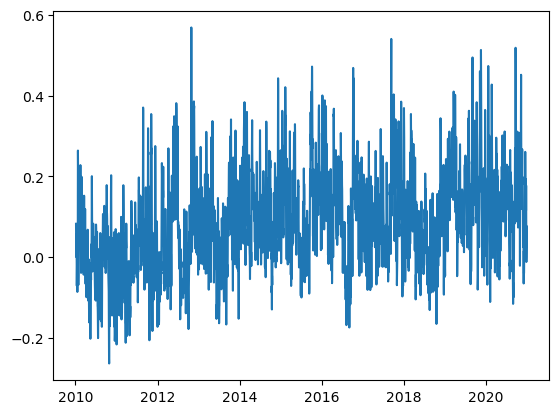

In [22]:

# Target = what we want to predict
TARGET_COLUMN = "residualTide"

# Columns that should not be used directly as predictors
# - time is a date column
# - slp was excluded in the original notebook
# - residualTide is the target, so it must not appear in X
EXCLUDE_COLUMNS = ["time", TARGET_COLUMN, "slp"]

feature_columns = [col for col in model_df.columns if col not in EXCLUDE_COLUMNS]

#print(feature_columns)

X = model_df[feature_columns]
y = model_df[TARGET_COLUMN]

plt.plot(model_df.time,y)
print(f"Number of predictors: {len(feature_columns)}")
print(feature_columns[:15])



## Time-based train/test split

For time series, it is usually better to train on earlier data and test on later data.
This avoids information leakage from the future.


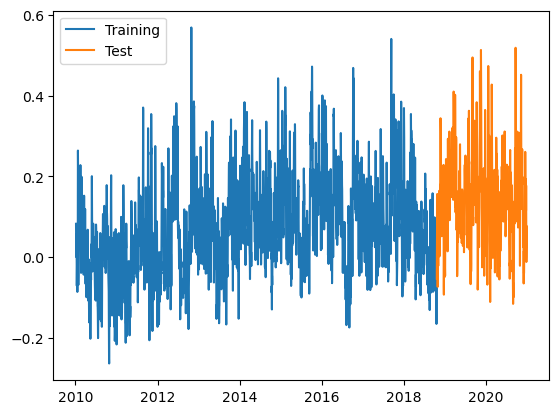

Training rows: 3210
Testing rows:  803
Train period: 2010-01-06 00:00:00 to 2018-10-20 00:00:00
Test period:  2018-10-21 00:00:00 to 2020-12-31 00:00:00


In [24]:

# Determine the split point based on time order
split_index = int(len(model_df) * (1 - TEST_FRACTION))

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]

X_test = test_df[feature_columns]
y_test = test_df[TARGET_COLUMN]

fig, ax = plt.subplots()
plt.plot(train_df['time'],y_train)
plt.plot(test_df['time'],y_test)
ax.legend(['Training','Test'])
plt.show()

print(f"Training rows: {len(train_df)}")
print(f"Testing rows:  {len(test_df)}")
print(f"Train period: {train_df['time'].min()} to {train_df['time'].max()}")
print(f"Test period:  {test_df['time'].min()} to {test_df['time'].max()}")


## Train models

All models below use the **same predictors**, the **same time-based train/test split**, and the **same target variable**. That makes the comparison fair and easy to explain in class.

### Parameter notes for the tree-based models

**Random Forest**
- `n_estimators`: number of trees in the forest. More trees usually improve stability, but increase run time.
- `max_depth`: maximum depth of each tree. Larger depth can capture more complexity, but may overfit.
- `random_state`: fixes the random seed so results are reproducible.
- `n_jobs`: number of CPU cores used during training. `-1` means use all available cores.

**Gradient Boosting**
- `n_estimators`: number of boosting stages (small trees added one after another).
- `learning_rate`: how much each new tree contributes. Smaller values are usually safer but may require more trees.
- `max_depth`: complexity of each weak learner (individual tree).
- `random_state`: keeps the training result reproducible.

**XGBoost**
- `n_estimators`: number of boosted trees.
- `learning_rate`: step size used when adding each new tree.
- `max_depth`: maximum depth of each tree.
- `subsample`: fraction of training rows used per tree. Values below 1.0 can reduce overfitting.
- `colsample_bytree`: fraction of predictor columns used per tree. This can also reduce overfitting.
- `objective="reg:squarederror"`: tells XGBoost to solve a regression problem using squared-error loss.
- `random_state`: fixes the random seed for reproducibility.
- `n_jobs`: number of CPU cores used in training.

### Parameter notes for the LSTM section
- `LSTM(32)`: the model has 32 memory units.
- `optimizer="adam"`: Adam updates weights efficiently during training.
- `loss="mse"`: mean squared error is minimized during training.
- `epochs`: maximum number of passes through the training data.
- `batch_size`: number of samples processed before the model updates its weights.
- `validation_split`: fraction of the training set used to monitor validation loss.
- `patience`: number of epochs to wait before early stopping if validation loss does not improve.


In [27]:
# ------------------------------------------------------------
# A. Random Forest
# ------------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)

# ------------------------------------------------------------
# B. Gradient Boosting
# ------------------------------------------------------------
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=10,
    random_state=42,
)

# ------------------------------------------------------------
# C. XGBoost
# ------------------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

# Fit the tree-based models on the training period
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Make predictions on the testing period
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print('Done')

In [28]:
# ------------------------------------------------------------
# D. LSTM neural network
# ------------------------------------------------------------
# Neural networks usually work better when inputs are scaled.
# Here we scale the predictor matrix using only the training data
# so that information from the test period does not leak backward.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LSTM layers expect 3D input:
#   (number of samples, number of time steps, number of features)
#
# To keep the notebook structure simple, we treat each predictor vector
# as a short sequence of length = number of predictors, with 1 value per step.
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Set random seeds so classroom results are more reproducible.
np.random.seed(42)
tf.random.set_seed(42)

# Build a small LSTM model suitable for demonstration.
lstm_model = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

# Stop early if the validation loss stops improving.
# This keeps training shorter and helps avoid overfitting.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the LSTM model.
# verbose=1 lets students see training progress.
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.10,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict on the testing period.
lstm_pred = lstm_model.predict(X_test_lstm, verbose=0).flatten()

Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0129 - val_loss: 0.0084
Epoch 2/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0119 - val_loss: 0.0085
Epoch 3/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0118 - val_loss: 0.0087
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0118 - val_loss: 0.0088
Epoch 5/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0117 - val_loss: 0.0088
Epoch 6/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0117 - val_loss: 0.0089


## Evaluate model performance

We compare all four models on the **same testing period** using standard regression metrics:
- **MAE**: average absolute error
- **MSE**: average squared error
- **RMSE**: square root of MSE, in the same units as the target

Lower values indicate better prediction performance. In a classroom setting, this table is a good place to discuss tradeoffs between model complexity, interpretability, and accuracy.


In [32]:
rf_metrics = evaluate_regression(y_test, rf_pred)
gb_metrics = evaluate_regression(y_test, gb_pred)
xgb_metrics = evaluate_regression(y_test, xgb_pred)
lstm_metrics = evaluate_regression(y_test, lstm_pred)

metrics_df = pd.DataFrame(
    [rf_metrics, gb_metrics, xgb_metrics, lstm_metrics],
    index=["Random Forest", "Gradient Boosting", "XGBoost", "LSTM"]
)

metrics_df = metrics_df[["MAE", "RMSE", "R2", "MSE"]]
metrics_df.round(3)


,MAE,RMSE,R2,MSE
Random Forest,0.081,0.100,0.165,0.010
Gradient Boosting,0.083,0.103,0.106,0.011
XGBoost,0.079,0.097,0.210,0.009
LSTM,0.097,0.123,-0.263,0.015


## Compare model metrics with bar charts

These plots make it easier to compare the models at a glance.

- **MAE** and **RMSE**: lower is better  
- **R²**: higher is better  

XGBoost is included directly in the same comparison frame as Random Forest,
Gradient Boosting, and LSTM.

<Figure size 1000x500 with 0 Axes>

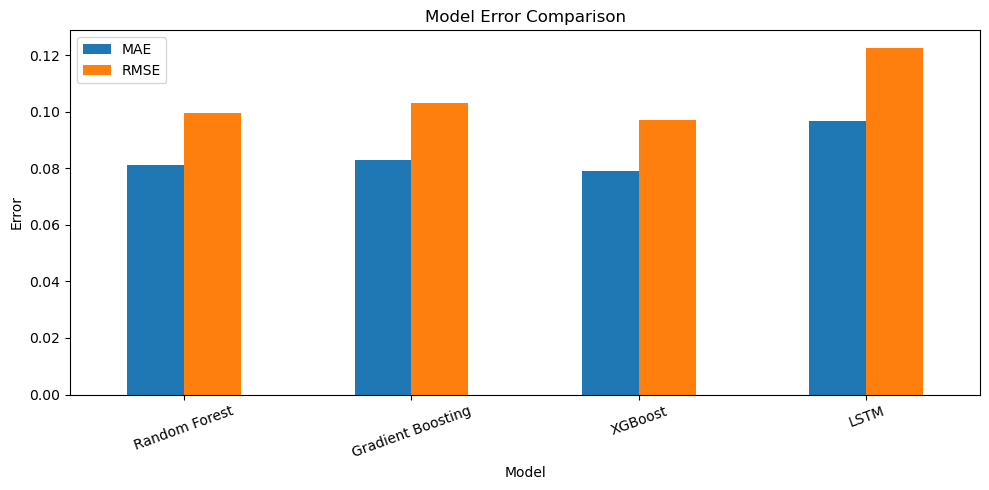

In [35]:
plt.figure(figsize=(10, 5))
metrics_df[["MAE", "RMSE"]].plot(kind="bar", figsize=(10, 5))
plt.ylabel("Error")
plt.xlabel("Model")
plt.title("Model Error Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

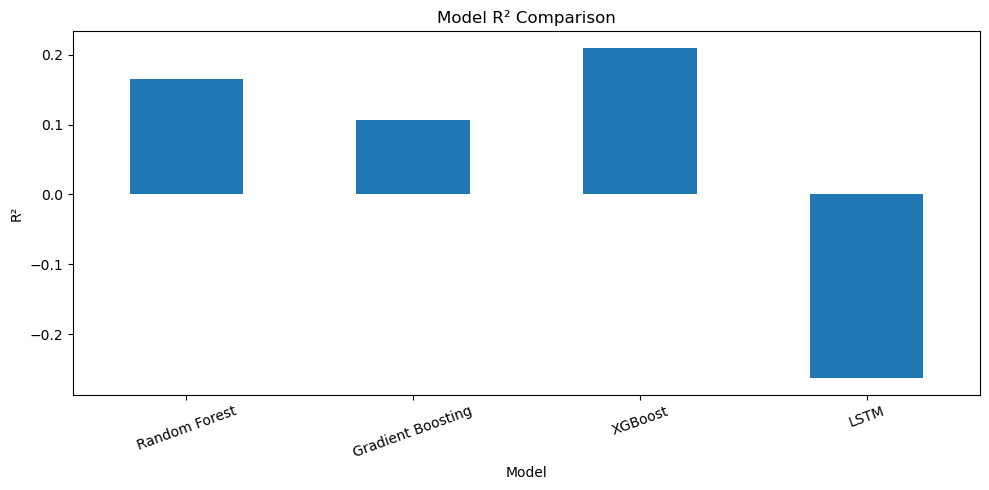

In [37]:
plt.figure(figsize=(10, 5))
metrics_df["R2"].plot(kind="bar", figsize=(10, 5))
plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Model R² Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Compare observed and predicted values

The plot below overlays the observed series with the predictions from all models on the **test period only**.
This helps students see not only which model has the lowest error, but also **when** each model tracks peaks, dips, and turning points well or poorly.


In [40]:
# Build a small table for plotting and inspection
pred_df = pd.DataFrame({
    "time": test_df["time"].values,
    "Actual": y_test.values,
    "RF_Predicted": rf_pred,
    "GB_Predicted": gb_pred,
    "XGB_Predicted": xgb_pred,
    "LSTM_Predicted": lstm_pred,
})

pred_df.head()


,time,Actual,RF_Predicted,GB_Predicted,XGB_Predicted,LSTM_Predicted
0,2018-10-21,-0.053292,0.035984,0.006317,0.035342,0.040325
1,2018-10-22,0.011083,0.068006,0.097012,0.080771,0.020169
2,2018-10-23,0.022958,0.113259,0.157341,0.101891,0.035073
3,2018-10-24,0.091292,0.158786,0.220739,0.166661,0.043483
4,2018-10-25,0.156250,0.153482,0.123830,0.209274,0.060367


## Scatter comparison: observed vs predicted

A scatter plot helps show how closely each model follows the 1:1 line.
Points closer to that line indicate better agreement between observations and predictions.

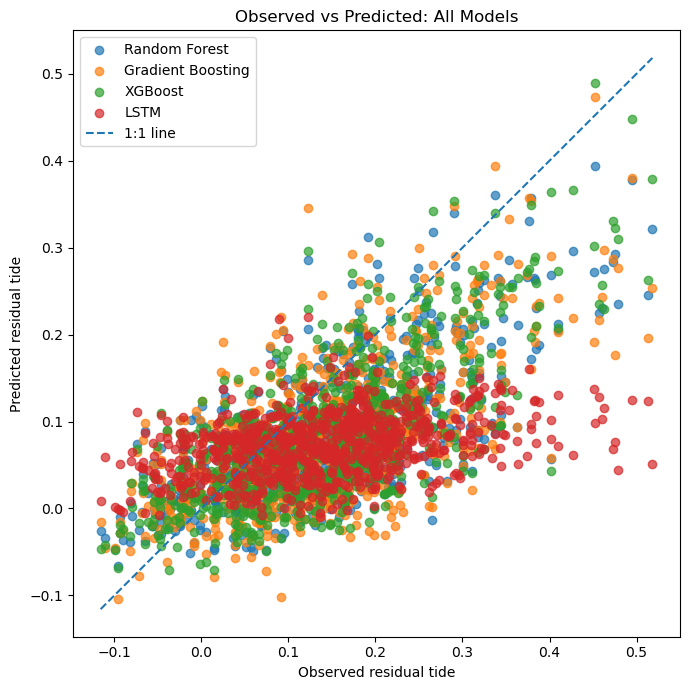

In [43]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, rf_pred, label="Random Forest", alpha=0.7)
plt.scatter(y_test, gb_pred, label="Gradient Boosting", alpha=0.7)
plt.scatter(y_test, xgb_pred, label="XGBoost", alpha=0.7)
plt.scatter(y_test, lstm_pred, label="LSTM", alpha=0.7)

min_val = min(y_test.min(), rf_pred.min(), gb_pred.min(), xgb_pred.min(), lstm_pred.min())
max_val = max(y_test.max(), rf_pred.max(), gb_pred.max(), xgb_pred.max(), lstm_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="1:1 line")

plt.xlabel("Observed residual tide")
plt.ylabel("Predicted residual tide")
plt.title("Observed vs Predicted: All Models")
plt.legend()
plt.tight_layout()
plt.show()

## Residual comparison

Residuals are defined as:

**Residual = observed - predicted**

A model with residuals clustered more tightly around zero is generally performing better.

In [46]:
residual_df = pd.DataFrame({
    "Random Forest": y_test.values - rf_pred,
    "Gradient Boosting": y_test.values - gb_pred,
    "XGBoost": y_test.values - xgb_pred,
    "LSTM": y_test.values - lstm_pred,
})

residual_df.describe().round(3)

,Random Forest,Gradient Boosting,XGBoost,LSTM
count,803.000,803.000,803.000,803.000
mean,0.059,0.059,0.057,0.068
std,0.080,0.085,0.079,0.102
min,-0.163,-0.223,-0.173,-0.184
25%,0.001,-0.002,-0.000,-0.004
50%,0.061,0.059,0.055,0.064
75%,0.113,0.113,0.110,0.132
max,0.345,0.344,0.359,0.468


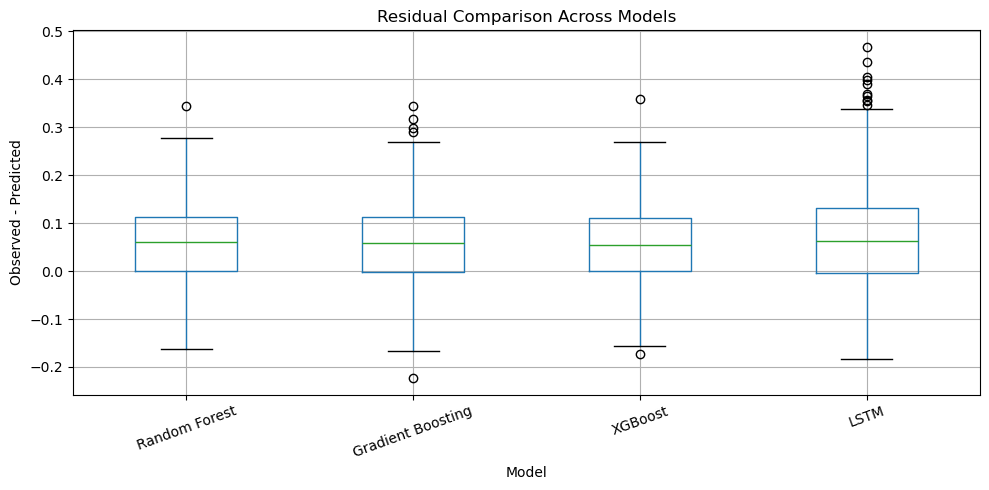

In [48]:
plt.figure(figsize=(10, 5))
residual_df.boxplot()
plt.ylabel("Observed - Predicted")
plt.xlabel("Model")
plt.title("Residual Comparison Across Models")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

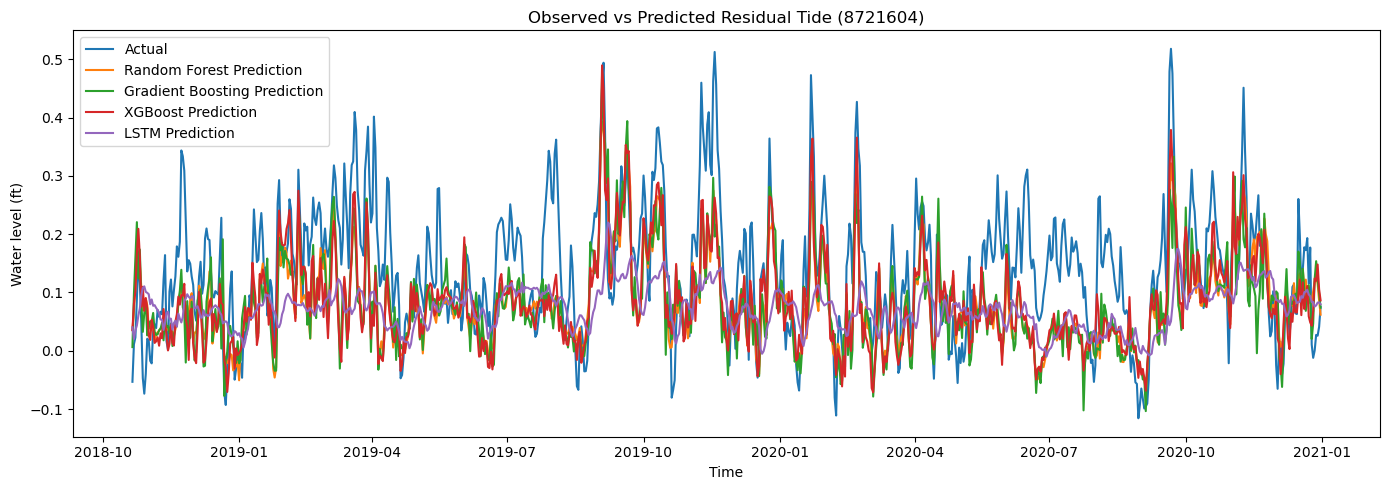

In [50]:
plt.figure(figsize=(14, 5))
plt.plot(pred_df["time"], pred_df["Actual"], label="Actual")
plt.plot(pred_df["time"], pred_df["RF_Predicted"], label="Random Forest Prediction")
plt.plot(pred_df["time"], pred_df["GB_Predicted"], label="Gradient Boosting Prediction")
plt.plot(pred_df["time"], pred_df["XGB_Predicted"], label="XGBoost Prediction")
plt.plot(pred_df["time"], pred_df["LSTM_Predicted"], label="LSTM Prediction")
plt.ylabel("Water level (ft)")
plt.xlabel("Time")
plt.title(f"Observed vs Predicted Residual Tide ({STATION_SHEET})")
plt.legend()
plt.tight_layout()
plt.show()


## LSTM training history

This plot shows how the LSTM loss changes during training.
- **Training loss** shows how well the model fits the training subset.
- **Validation loss** shows how well it generalizes to held-out data from the training period.

If validation loss stops improving while training loss keeps dropping, the model may be starting to overfit.


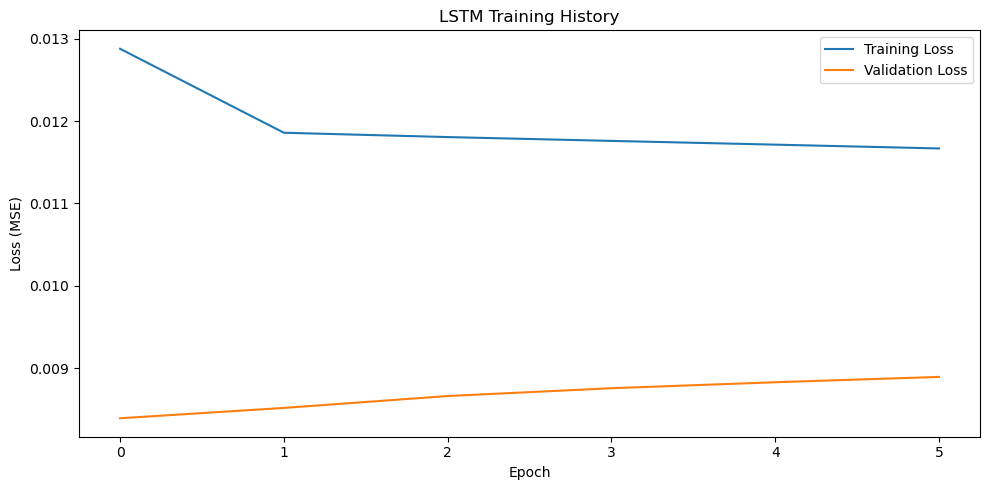

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("LSTM Training History")
plt.legend()
plt.tight_layout()
plt.show()


## Feature importance plot

Tree-based models can estimate which predictors were most useful during training.
Below, we first inspect **Random Forest** feature importance and then **XGBoost** feature importance. These scores are helpful for classroom discussion, but they should not be interpreted as strict causality.


In [56]:
# Create a pandas Series so feature names stay attached to their importance values
rf_feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print("Top 15 Random Forest features")
display(rf_feature_importance.head(15).to_frame("RF importance"))

print("Top 15 XGBoost features")
display(xgb_feature_importance.head(15).to_frame("XGBoost importance"))


Top 15 Random Forest features


,RF importance
Transport,0.432082
newslp,0.045153
newV10,0.039949
precip,0.033908
newUV10Mag,0.029764
CRW_SSTANOMALY,0.022409
newU10,0.017595
UVwndMag20.0,0.014141
newUVDir,0.012276
Transport_lag5,0.010379


Top 15 XGBoost features


,XGBoost importance
Transport,0.105952
Transport_lag1,0.073964
precip,0.024202
newV10,0.022016
newslp,0.018203
UVwndMag20.0,0.018022
newUV10Mag,0.017750
CRW_SST_lag4,0.015526
uwnd30.0,0.014874
CRW_SSTANOMALY,0.014456


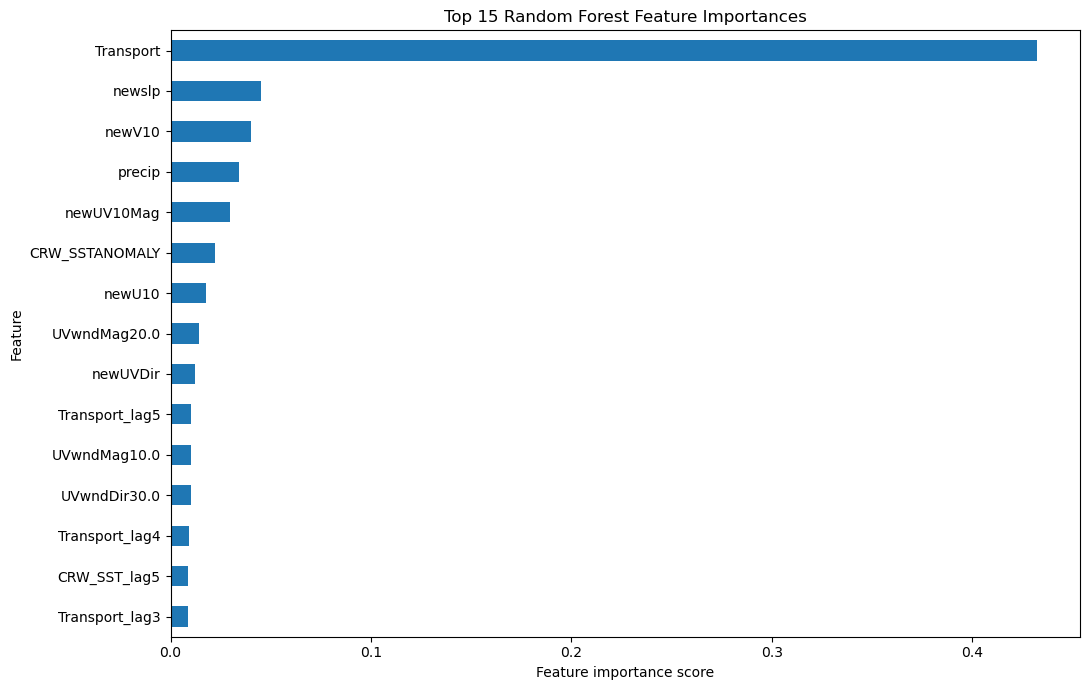

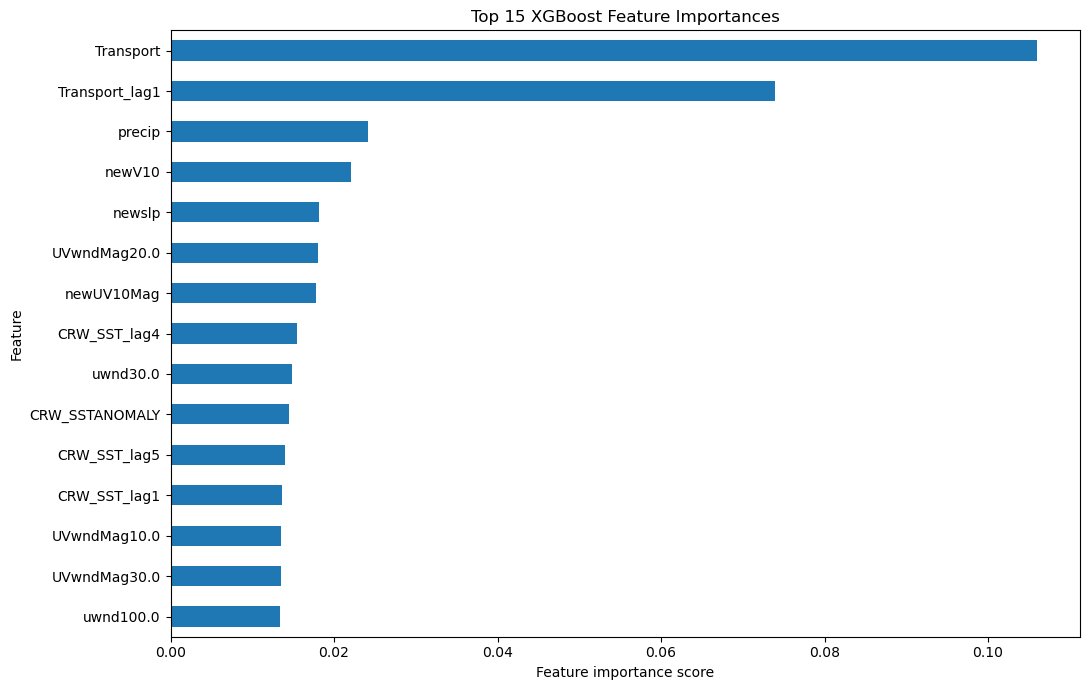

In [58]:
# Plot the top 15 Random Forest features
plt.figure(figsize=(11, 7))
rf_feature_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature importance score")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# Plot the top 15 XGBoost features
plt.figure(figsize=(11, 7))
xgb_feature_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature importance score")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()



## Optional: save outputs

Uncomment these lines if you want to save the evaluation table or predictions.


In [ ]:
# metrics_df.to_csv("model_metrics_cleaned.csv")
# pred_df.to_csv("predictions_cleaned.csv", index=False)
# rf_feature_importance.to_csv("rf_feature_importance.csv")
# xgb_feature_importance.to_csv("xgb_feature_importance.csv")
